# Chronos-2 on the BIH air-quality data - multivariate, weather-informed forecasting

Same frozen evaluation windows and the same `bih_shared` scoring pipeline as
`chronos_forecast.ipynb`, but swapping **Chronos-Bolt** for **Chronos-2**
(released 20 Oct 2025) and using two of its capabilities Chronos-Bolt didn't
have:

1. **Multivariate targets.** PM10 and PM2.5 are forecast *jointly* per station
   instead of as two independent univariate calls, so the model can use each
   pollutant's history to inform the other (they share sources - traffic,
   heating, inversions - and the `spatial_eda` correlation matrices confirm
   they move together within a station).
2. **Covariate-informed forecasting.** Chronos-2 natively accepts past and
   known-future covariates. We feed it weather, on the theory the `spatial_eda`
   notebook's biggest finding motivates directly: the winter/summer PM10
   swing is large (Ilijas: +65 ug/m3 winter vs summer) and station-specific,
   which looks like a heating + temperature-inversion signature - exactly
   what temperature, pressure, humidity, and wind should help explain, and
   exactly what a purely calendar-based `doy_sin/doy_cos` feature (as used in
   `gnn_spatial.ipynb`) cannot capture in a given year's weather anomaly.

**Zero-shot, like the Bolt run.** Nothing is trained or fine-tuned here either.

**Important caveat on "future" weather.** Chronos-2 wants *known* future
covariate values for the forecast horizon. We don't have an archived weather
*forecast* for 2024, so `future_df` is populated with the actual observed
weather for those hours - i.e. this is an oracle-covariate run, not a
deployable pipeline. It answers "how much would perfect weather knowledge
help this model", not "how well would this work with a real weather
forecast feed". Report it as such; a fair deployable version would need
ERA5/GFS reanalysis-as-forecast or an actual NWP archive swapped in for
`future_df`.

**Weather comes straight from `bih_hourly_clean.csv`.** `eda.ipynb` already
joins station-level weather (temperature, wind speed, humidity, pressure)
into the same hourly file the pollutants come from, wind direction already
decomposed into `wind_u`/`wind_v` components, and with the same short-gap
interpolation + `_filled` flagging the pollutants get. So no external API is
needed here - `bs.load_panel`'s underlying CSV (already downloaded in the
bootstrap cell) is read a second time for its weather columns, keyed by the
same `station` + `datetime` used everywhere else in this pipeline.

**Everything else is unchanged from the Bolt notebook**: the split, the
frozen windows, the `_filled` masking rule, and the baseline comparison all
come from the same shared artifacts, so the three tracks stay comparable.

In [ ]:
# ---- bootstrap: shared artifacts + the dataset --------------------------
SHARED_FOLDER_ID = "1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE"
CLEAN_FILE_ID    = "1QyfzghimgyRhQ735k42JetDEoK5kfGZJ"

SHARED = "shared"
CLEAN  = "bih_hourly_clean.csv"

import os, sys, json, subprocess, time
import numpy as np
import pandas as pd


def _gdown():
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    return gdown


if not os.path.exists(os.path.join(SHARED, "bih_shared.py")):
    print("fetching the shared artifacts")
    _gdown().download_folder(id=SHARED_FOLDER_ID, output=SHARED, quiet=True)

if not os.path.exists(CLEAN) or os.path.getsize(CLEAN) < 1e8:
    print("fetching bih_hourly_clean.csv (~167 MB)")
    _gdown().download(id=CLEAN_FILE_ID, output=CLEAN, quiet=False)

for path, what in [(os.path.join(SHARED, "bih_shared.py"), "the shared folder"),
                   (CLEAN, "bih_hourly_clean.csv")]:
    if not os.path.exists(path):
        raise SystemExit(
            f"{path} is missing - the download of {what} failed. Check the ID "
            f"and that it is shared as 'Anyone with the link'."
        )

sys.path.append(SHARED)
import bih_shared as bs

SPLIT   = bs.load_split(SHARED)
GROUPS  = bs.load_groups(SHARED)
RESULTS = "results_chronos2"
os.makedirs(RESULTS, exist_ok=True)

print("shared :", os.path.abspath(SHARED))
print("clean  :", CLEAN, f"({os.path.getsize(CLEAN) / 1e6:.0f} MB)")
print("split  : train", SPLIT["train"]["start"][:10], "->", SPLIT["train"]["end"][:10],
      "| val", SPLIT["val"]["start"][:10], "->", SPLIT["val"]["end"][:10])

In [2]:
# ---- install Chronos-2 ---------------------------------------------------
# Chronos-2 ships in chronos-forecasting>=2.0 as a separate pipeline class
# (Chronos2Pipeline) alongside the older BaseChronosPipeline used for Bolt.
try:
    import chronos
    from chronos import Chronos2Pipeline
    assert hasattr(chronos, "Chronos2Pipeline")
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting>=2.0"], check=True)
    import chronos
    from chronos import Chronos2Pipeline

import torch

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())

torch 2.11.0+cu128 | cuda: True


## Configuration

`amazon/chronos-2` is the only size Chronos-2 ships in (120M params) - there's
no `-small`/`-mini` tier the way Bolt has one. It's fast enough (300+
series/s on a single A10G per Amazon's numbers) to run on CPU for a smoke
test, but plan on a GPU runtime for the full window set.

`CONTEXT` stays independent of the shared split for the same reason as the
Bolt notebook: Chronos wants a lot of history (up to 8,192 h for Chronos-2,
vastly more than Bolt's 2,048 h cap) and forcing that onto the GNN/xLSTM
tracks would shrink their window list.

`TARGETS` is the multivariate switch: passing a list makes `predict_df`
forecast both columns jointly for each id, instead of one call per pollutant.

`WEATHER_COLS` are the station-level weather fields already sitting in
`bih_hourly_clean.csv` (see `eda.ipynb`): `temperature`, `wind_speed`,
`humidity`, `pressure`, and the `wind_u`/`wind_v` vector components (wind
direction was decomposed there already, so there's no raw 0-360 degree
column to worry about here).

In [3]:
MODEL   = "amazon/chronos-2"
CONTEXT = 512      # hours of history fed to the model (kept equal to the Bolt run for comparability)
BATCH   = 32       # windows per predict_df call; multivariate + covariates cost more memory than Bolt's univariate call, so start lower than Bolt's 64

HORIZON   = SPLIT["horizon_hours"]
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]   # same 9 levels as the Bolt run, so WQL is comparable across tracks

TARGETS = ["pm10", "pm25"]        # forecast jointly, multivariate

USE_WEATHER = True                # set False to run the no-covariate ablation (see the ablation cell near the end)
WEATHER_COLS = ["temperature", "wind_speed", "humidity", "pressure", "wind_u", "wind_v"]

SUBSET_STATIONS = None   # e.g. ["Ilijas", "Banja Luka"] to smoke-test on a couple of stations first

## Load the panel and build the joint PM10+PM25 window list

The frozen windows are per station x pollutant x origin. A joint forecast
needs a PM10 window and a PM2.5 window that share the same `(station,
origin)`, so we inner-join on that pair. Stations that only report one of
the two pollutants (see the `gnn_eda` notebook: 19 stations have real PM10,
only 16 have real PM2.5) simply lose whichever windows don't have a
partner - reported below so it isn't a silent drop.

In [ ]:
panel = bs.load_panel(CLEAN, SHARED)
wins  = bs.load_windows(SHARED)
wins  = wins[wins.pollutant.isin(TARGETS)].reset_index(drop=True)

if SUBSET_STATIONS:
    wins = wins[wins.station.isin(SUBSET_STATIONS)].reset_index(drop=True)

# keep only (station, origin) pairs where BOTH pm10 and pm25 windows exist
pair_counts = wins.groupby(["station", "origin"])["pollutant"].transform("nunique")
joint = wins[pair_counts == len(TARGETS)].copy()
dropped = wins[pair_counts < len(TARGETS)]

meta_cols = [c for c in ["source", "city"] if c in wins.columns]
jobs = (joint[joint.pollutant == TARGETS[0]]
        [["station", "origin", *meta_cols]]
        .drop_duplicates()
        .reset_index(drop=True))
jobs["uid"] = jobs.station.astype(str) + "__" + jobs.origin.astype("int64").astype(str)

print(f"{len(panel)} series in the panel")
print(f"{wins.groupby(['station','pollutant']).ngroups} station-pollutant series across {TARGETS}")
print(f"{len(jobs):,} joint (pm10, pm25) windows kept, "
      f"{dropped.station.nunique()} stations lost at least one window to the pairing "
      f"({dropped.shape[0]} unpaired windows dropped)")
print(f"origins {jobs.origin.min()} -> {jobs.origin.max()}")

## Weather covariates (already in `bih_hourly_clean.csv`)

`eda.ipynb`'s cleaning pass writes `temperature`, `wind_speed`, `humidity`,
`pressure` alongside the pollutants, filled the same way (linear
interpolation for gaps <= 3 h, `NaN` left alone otherwise, each flagged with
its own `_filled` column) and adds `wind_u`/`wind_v` - wind speed and
direction already decomposed into vector components, since raw compass
degrees are circular and a model would otherwise see 359 deg and 1 deg as
nearly opposite instead of nearly identical.

That's the same `bih_hourly_clean.csv` the bootstrap cell already downloaded
for the pollutant panel, so this just reads it a second time and pivots the
weather columns into one DataFrame per station, indexed by `datetime`.

Calendar features (`hour_sin/cos`, `doy_sin/cos`) are added alongside the
weather - they cost nothing to compute and, unlike weather, are *exactly*
known for the forecast horizon (no oracle caveat applies to them).

In [5]:
_wx_need = ["datetime", "station", *WEATHER_COLS]
_hdr = pd.read_csv(CLEAN, nrows=0).columns.tolist()
_missing = [c for c in _wx_need if c not in _hdr]
if _missing:
    raise SystemExit(
        f"\n{CLEAN} is missing weather columns: {_missing}\n"
        f"This notebook expects the bih_hourly_clean.csv produced by eda.ipynb, "
        f"which joins temperature/wind_speed/humidity/pressure/wind_u/wind_v "
        f"onto the pollutant panel. Re-run eda.ipynb's cleaned-export cell if "
        f"CLEAN_FILE_ID points at an older export."
    )

_wx_raw = pd.read_csv(CLEAN, usecols=_wx_need, parse_dates=["datetime"])
weather = {
    station: g.drop(columns="station").set_index("datetime").sort_index()
    for station, g in _wx_raw.groupby("station")
}
del _wx_raw

print(f"weather loaded for {len(weather)} stations directly from {CLEAN}")
print("columns:", WEATHER_COLS)
missing_stations = sorted(set(jobs.station) - set(weather))
if missing_stations:
    print(f"! no weather rows at all for: {missing_stations} - these will fall back to calendar-only covariates")

weather loaded for 23 stations directly from bih_hourly_clean.csv
columns: ['temperature', 'wind_speed', 'humidity', 'pressure', 'wind_u', 'wind_v']


## Covariate helper

Builds the weather + calendar covariate matrix for an arbitrary list of
hourly timestamps for one station. The clean CSV already interpolated gaps
<= 3 h; this adds a slightly more generous interpolate/ffill/bfill pass
(limit=6 h) on top purely so a handful of longer weather gaps don't blow a
hole in a context or horizon window - it does not touch the pollutant
targets themselves, only the covariates. Stations with no weather rows at
all fall back to calendar-only covariates rather than crashing the run.

In [6]:
def calendar_features(ts):
    hour = ts.hour.values
    doy  = ts.dayofyear.values
    return pd.DataFrame({
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "doy_sin":  np.sin(2 * np.pi * doy / 365.25),
        "doy_cos":  np.cos(2 * np.pi * doy / 365.25),
    }, index=ts)


def covariates(station, ts):
    cal = calendar_features(ts)
    if not USE_WEATHER or station not in weather:
        return cal
    wx = (weather[station]
          .reindex(ts)
          .interpolate(limit=6)
          .ffill(limit=6)
          .bfill(limit=6))
    return pd.concat([wx, cal], axis=1)


COV_COLS = (WEATHER_COLS if USE_WEATHER else []) + ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
print("covariates fed to Chronos-2:", COV_COLS)

covariates fed to Chronos-2: ['temperature', 'wind_speed', 'humidity', 'pressure', 'wind_u', 'wind_v', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## Coverage check

How much real pollutant history and how much clean weather each window
actually has, before spending compute on it - the same fail-fast instinct
as the Bolt notebook's context-coverage cell, extended to weather.

In [7]:
def _coverage_row(row):
    ts_hist = pd.date_range(end=row.origin - pd.Timedelta(hours=1), periods=CONTEXT, freq="h")
    pm10_cov = np.isfinite(bs.context(panel, row.station, "pm10", row.origin, CONTEXT)).mean()
    pm25_cov = np.isfinite(bs.context(panel, row.station, "pm25", row.origin, CONTEXT)).mean()
    wx_cov = (covariates(row.station, ts_hist)[WEATHER_COLS].notna().mean().mean()
              if USE_WEATHER and WEATHER_COLS else np.nan)
    return pm10_cov, pm25_cov, wx_cov

cov = jobs.apply(_coverage_row, axis=1, result_type="expand")
cov.columns = ["pm10_ctx_real", "pm25_ctx_real", "weather_ctx_real"]
jobs = pd.concat([jobs, cov], axis=1)

print("pollutant context coverage over", CONTEXT, "h")
print(jobs[["pm10_ctx_real", "pm25_ctx_real"]].describe().loc[["mean", "min"]].to_string())
if USE_WEATHER:
    print(f"\nweather context coverage: mean {jobs.weather_ctx_real.mean():.3f}, "
          f"{(jobs.weather_ctx_real < 0.9).sum():,} windows below 90%")

pollutant context coverage over 512 h
      pm10_ctx_real  pm25_ctx_real
mean       0.979347       0.977603
min        0.021484       0.021484

weather context coverage: mean 0.707, 2,574 windows below 90%


## Forecast

`Chronos2Pipeline.predict_df` takes long-format tables: `context_df` carries
the target column(s) plus any past covariates, `future_df` carries the
known-future covariates for the horizon (no target columns - that's what
makes them the thing being predicted). Multiple windows are batched into one
call by giving each `(station, origin)` pair its own `id`; Chronos-2 treats
each id as an independent series but can share its in-context-learning
representations across them within the same call.

In [ ]:
pipeline = Chronos2Pipeline.from_pretrained(
    MODEL,
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.float32,
)
print("loaded", MODEL)

In [9]:
def build_batch_frames(batch):
    '''Long-format context_df / future_df for one batch of joint windows.'''
    ctx_parts, fut_parts = [], []
    for row in batch.itertuples():
        ts_hist = pd.date_range(end=row.origin - pd.Timedelta(hours=1), periods=CONTEXT, freq="h")
        ts_fut  = pd.date_range(start=row.origin, periods=HORIZON, freq="h")

        hist = pd.DataFrame({
            "id": row.uid,
            "timestamp": ts_hist,
            "pm10": bs.context(panel, row.station, "pm10", row.origin, CONTEXT),
            "pm25": bs.context(panel, row.station, "pm25", row.origin, CONTEXT),
        })
        hist = pd.concat([hist.set_index("timestamp"), covariates(row.station, ts_hist)],
                          axis=1).reset_index().rename(columns={"index": "timestamp"})

        fut = pd.DataFrame({"id": row.uid, "timestamp": ts_fut}).set_index("timestamp")
        fut = pd.concat([fut, covariates(row.station, ts_fut)], axis=1).reset_index() \
                .rename(columns={"index": "timestamp"})

        ctx_parts.append(hist)
        fut_parts.append(fut)

    return pd.concat(ctx_parts, ignore_index=True), pd.concat(fut_parts, ignore_index=True)


def forecast_all(jobs, batch=BATCH):
    '''Run every joint window through Chronos-2, batched. Returns {(uid, target): quantile array}.'''
    out = {}
    t0 = time.time()
    for i in range(0, len(jobs), batch):
        chunk = jobs.iloc[i:i + batch]
        context_df, future_df = build_batch_frames(chunk)

        pred_df = pipeline.predict_df(
            context_df,
            future_df=future_df,
            prediction_length=HORIZON,
            quantile_levels=QUANTILES,
            id_column="id",
            timestamp_column="timestamp",
            target=TARGETS,
        )

        q_cols = [str(q) for q in QUANTILES]
        for uid, g in pred_df.groupby("id"):
            for tgt, gg in g.groupby("target_name"):
                gg = gg.sort_values("timestamp")
                assert len(gg) == HORIZON, f"{uid}/{tgt}: expected {HORIZON} rows, got {len(gg)}"
                out[(uid, tgt)] = gg[q_cols].to_numpy()

        done = i + len(chunk)
        if done % (batch * 10) == 0 or done >= len(jobs):
            el = time.time() - t0
            print(f"  {done:>6,}/{len(jobs):,}  {el:5.0f}s elapsed, "
                  f"~{el / done * (len(jobs) - done):5.0f}s left")
    return out


preds = forecast_all(jobs)
print(f"\n{len(preds):,} (window, target) quantile forecasts collected")

     320/3,234     20s elapsed, ~  179s left
     640/3,234     35s elapsed, ~  140s left
     960/3,234     49s elapsed, ~  116s left
   1,280/3,234     64s elapsed, ~   97s left
   1,600/3,234     78s elapsed, ~   80s left
   1,920/3,234     93s elapsed, ~   64s left
   2,240/3,234    109s elapsed, ~   48s left
   2,560/3,234    125s elapsed, ~   33s left
   2,880/3,234    142s elapsed, ~   17s left
   3,200/3,234    158s elapsed, ~    2s left
   3,234/3,234    160s elapsed, ~    0s left

6,468 (window, target) quantile forecasts collected


## Score

Same `bs.target` / `bs.score` / `bs.mase_scale` functions as the Bolt
notebook, run once per pollutant so the two targets stay in the same
per-pollutant tables the baselines use. WQL is computed the same way as the
Bolt notebook too.

In [10]:
MEDIAN = QUANTILES.index(0.5)

all_rows, all_wql = [], []
for target in TARGETS:
    for row in jobs.itertuples():
        q = preds.get((row.uid, target))
        if q is None:
            continue   # e.g. a window Chronos-2 silently skipped for being too short - flagged below if it happens
        point = q[:, MEDIAN]

        y, mask = bs.target(panel, row.station, target, row.origin)
        ctx     = bs.context(panel, row.station, target, row.origin, CONTEXT)
        sc      = bs.score(point, y, mask, bs.mase_scale(ctx))

        yt = np.where(mask, y, np.nan)[:, None]
        lv = np.array(QUANTILES)[None, :]
        d  = yt - q
        pin = np.maximum(lv * d, (lv - 1) * d)
        den = np.nansum(np.abs(yt)) * len(QUANTILES)
        all_wql.append(np.nansum(pin) / den if den > 0 else np.nan)

        all_rows.append({
            "model": "chronos2", "station": row.station, "pollutant": target,
            "origin": row.origin, **{c: getattr(row, c) for c in meta_cols},
            **sc,
        })

res = pd.DataFrame(all_rows)
res["wql"] = all_wql
res["season"] = res.origin.dt.month.map(
    lambda m: "winter" if m in (12, 1, 2) else "spring" if m in (3, 4, 5)
    else "summer" if m in (6, 7, 8) else "autumn")

missing = len(jobs) * len(TARGETS) - len(res)
if missing:
    print(f"! {missing} (window, target) pairs had no forecast - check the forecast_all output above")

print(res.groupby("pollutant")[["mae", "rmse", "mase", "wql"]].describe().to_string(
    float_format=lambda v: f"{v:8.3f}"))

               mae                                                                    rmse                                                                    mase                                                                     wql                                                               
             count     mean      std      min      25%      50%      75%      max    count     mean      std      min      25%      50%      75%      max    count     mean      std      min      25%      50%      75%      max    count     mean      std      min      25%      50%      75%      max
pollutant                                                                                                                                                                                                                                                                                                
pm10      3234.000   10.894   14.114    0.337    3.202    6.122   12.556  175.205 3234.000   14.027   17.5

In [11]:
# The baselines are read, not recomputed - identical windows by construction,
# same as the Bolt notebook. If chronos_window_metrics.csv from a prior Bolt
# run is sitting in ../results, it's pulled in too for a three-way comparison.
base = pd.read_csv(os.path.join(SHARED, "baseline_windows.csv"), parse_dates=["origin"])
key = ["station", "pollutant", "origin"]
base = base.merge(res[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")

allm = pd.concat([base, res[base.columns.intersection(res.columns)]], ignore_index=True)

bolt_path = os.path.join("results", "chronos_window_metrics.csv")
if os.path.exists(bolt_path):
    bolt = pd.read_csv(bolt_path, parse_dates=["origin"])
    bolt = bolt.merge(res[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")
    bolt["model"] = "chronos_bolt"
    allm = pd.concat([allm, bolt[allm.columns.intersection(bolt.columns)]], ignore_index=True)
    print("chronos-bolt results found - included in the comparison")

print("windows per model - these must match within a pollutant:\n")
print(allm.groupby(["pollutant", "model"]).size().to_string())

windows per model - these must match within a pollutant:

pollutant  model           
pm10       chronos2            3234
           persistence_last    3234
           persistence_t24     3234
pm25       chronos2            3234
           persistence_last    3234
           persistence_t24     3234
           ratio_pm25          3230


## Results

In [12]:
per_pol = allm.pivot_table(index="pollutant", columns="model", values="mase")
if "persistence_t24" in per_pol.columns:
    per_pol["chronos2_vs_t24_%"] = (1 - per_pol.chronos2 / per_pol.persistence_t24) * 100
if "chronos_bolt" in per_pol.columns:
    per_pol["chronos2_vs_bolt_%"] = (1 - per_pol.chronos2 / per_pol.chronos_bolt) * 100

print("MASE BY POLLUTANT   (lower is better; positive % = Chronos-2 wins)\n")
print(per_pol.to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nMAE BY POLLUTANT, native units (ug/m3)\n")
print(allm.pivot_table(index="pollutant", columns="model", values="mae")
          .to_string(float_format=lambda v: f"{v:8.3f}"))

print(f"\n\nchronos2 WQL by pollutant (quantile loss, Chronos-only)\n")
print(res.groupby("pollutant").wql.mean().to_string(float_format=lambda v: f"{v:.4f}"))

MASE BY POLLUTANT   (lower is better; positive % = Chronos-2 wins)

model      chronos2  persistence_last  persistence_t24  ratio_pm25  chronos2_vs_t24_%
pollutant                                                                            
pm10          0.774             1.219            1.085         NaN             28.604
pm25          0.731             1.204            1.052       1.213             30.480


MAE BY POLLUTANT, native units (ug/m3)

model      chronos2  persistence_last  persistence_t24  ratio_pm25
pollutant                                                         
pm10         10.894            18.487           15.956         NaN
pm25          8.574            15.578           12.965      13.515


chronos2 WQL by pollutant (quantile loss, Chronos-only)

pollutant
pm10   0.1624
pm25   0.1614


In [13]:
print("MASE BY SEASON\n")
print(allm.pivot_table(index="season", columns="model", values="mase")
          .reindex(["winter", "spring", "summer", "autumn"])
          .to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nMASE BY STATION - Chronos-2 vs the t-24 bar\n")
idx = [c for c in ["source", "city", "station"] if c in allm.columns]
st = allm.pivot_table(index=idx, columns="model", values="mase")
if "persistence_t24" in st.columns:
    st["gain_%"] = (1 - st.chronos2 / st.persistence_t24) * 100
print(st.sort_values("gain_%", ascending=False).to_string(float_format=lambda v: f"{v:7.3f}")
      if "gain_%" in st.columns else st.to_string(float_format=lambda v: f"{v:7.3f}"))

MASE BY SEASON

model   chronos2  persistence_last  persistence_t24  ratio_pm25
season                                                         
winter     0.635             1.157            0.962       0.962
spring     0.681             1.042            0.963       1.141
summer     0.787             1.068            1.080       1.386
autumn     0.948             1.672            1.319       1.402


MASE BY STATION - Chronos-2 vs the t-24 bar

model                         chronos2  persistence_last  persistence_t24  ratio_pm25  gain_%
source city       station                                                                    
rhz    Brod       Brod           0.672             1.490            1.062       1.686  36.750
       Banja Luka Banja Luka     0.757             1.655            1.105       1.071  31.513
       Trebinje   Trebinje       0.700             0.905            1.019       1.217  31.275
fhz    Sarajevo   Bjelave        0.772             0.991            1.102       1.1

## Weather ablation (optional)

Re-runs the same joint PM10/PM25 forecast with `USE_WEATHER = False` (weather
columns dropped, calendar covariates kept) so the MASE gain attributable to
weather specifically - as opposed to the multivariate joint-target setup, or
Chronos-2 itself - is isolated. This doubles the compute cost of the run, so
it's split into its own cell rather than baked into the main loop; skip it
for a quick pass.

In [18]:
RUN_ABLATION = True   # flip to True to quantify weather's contribution specifically

if RUN_ABLATION:
    USE_WEATHER = False
    preds_noweather = forecast_all(jobs)

    rows_nw = []
    for target in TARGETS:
        for row in jobs.itertuples():
            q = preds_noweather.get((row.uid, target))
            if q is None:
                continue
            point = q[:, MEDIAN]
            y, mask = bs.target(panel, row.station, target, row.origin)
            ctx     = bs.context(panel, row.station, target, row.origin, CONTEXT)
            sc      = bs.score(point, y, mask, bs.mase_scale(ctx))
            rows_nw.append({"model": "chronos2_no_weather", "pollutant": target,
                             "station": row.station, "origin": row.origin, **sc})

    res_nw = pd.DataFrame(rows_nw)
    cmp = pd.concat([res.assign(model="chronos2"), res_nw])
    print(cmp.pivot_table(index="pollutant", columns="model", values="mase")
             .to_string(float_format=lambda v: f"{v:8.3f}"))

    USE_WEATHER = True   # restore for any cells re-run after this one

     320/3,234     11s elapsed, ~   98s left
     640/3,234     22s elapsed, ~   89s left
     960/3,234     33s elapsed, ~   78s left
   1,280/3,234     43s elapsed, ~   65s left
   1,600/3,234     51s elapsed, ~   53s left
   1,920/3,234     60s elapsed, ~   41s left
   2,240/3,234     68s elapsed, ~   30s left
   2,560/3,234     77s elapsed, ~   20s left
   2,880/3,234     85s elapsed, ~   11s left
   3,200/3,234     94s elapsed, ~    1s left
   3,234/3,234     95s elapsed, ~    0s left
model      chronos2  chronos2_no_weather
pollutant                               
pm10          0.774                0.813
pm25          0.731                0.777


## Plots

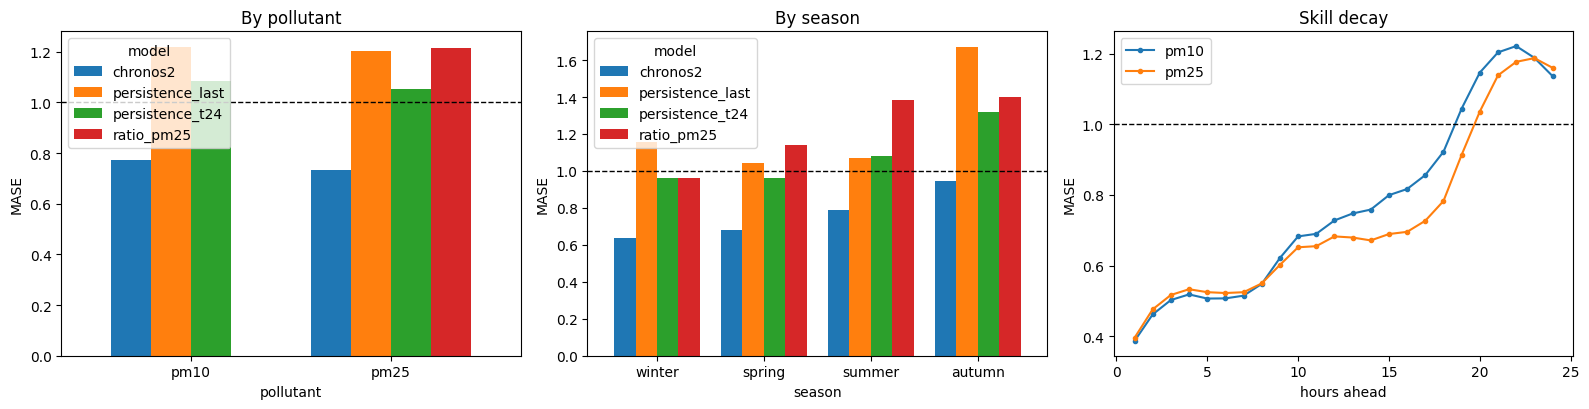

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

drop_cols = [c for c in per_pol.columns if c.endswith("_%")]
per_pol.drop(columns=drop_cols).plot.bar(ax=axes[0], width=.8)
axes[0].axhline(1, color="k", ls="--", lw=1)
axes[0].set_ylabel("MASE"); axes[0].set_title("By pollutant")
axes[0].tick_params(axis="x", rotation=0)

(allm.pivot_table(index="season", columns="model", values="mase")
     .reindex(["winter", "spring", "summer", "autumn"]).plot.bar(ax=axes[1], width=.8))
axes[1].axhline(1, color="k", ls="--", lw=1)
axes[1].set_ylabel("MASE"); axes[1].set_title("By season")
axes[1].tick_params(axis="x", rotation=0)

h = np.arange(1, HORIZON + 1)
for target, color in zip(TARGETS, ["tab:blue", "tab:orange"]):
    sub = res[res.pollutant == target]
    curves = []
    for row in jobs.itertuples():
        q = preds.get((row.uid, target))
        if q is None:
            continue
        y, mask = bs.target(panel, row.station, target, row.origin)
        ctx = bs.context(panel, row.station, target, row.origin, CONTEXT)
        scale = bs.mase_scale(ctx)
        curves.append(np.where(mask, np.abs(q[:, MEDIAN] - y) / scale, np.nan))
    axes[2].plot(h, np.nanmean(np.array(curves), axis=0), "o-", ms=3, color=color, label=target)
axes[2].axhline(1, color="k", ls="--", lw=1)
axes[2].set_xlabel("hours ahead"); axes[2].set_ylabel("MASE")
axes[2].set_title("Skill decay"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "chronos2_skill.png"), dpi=150)
plt.show()

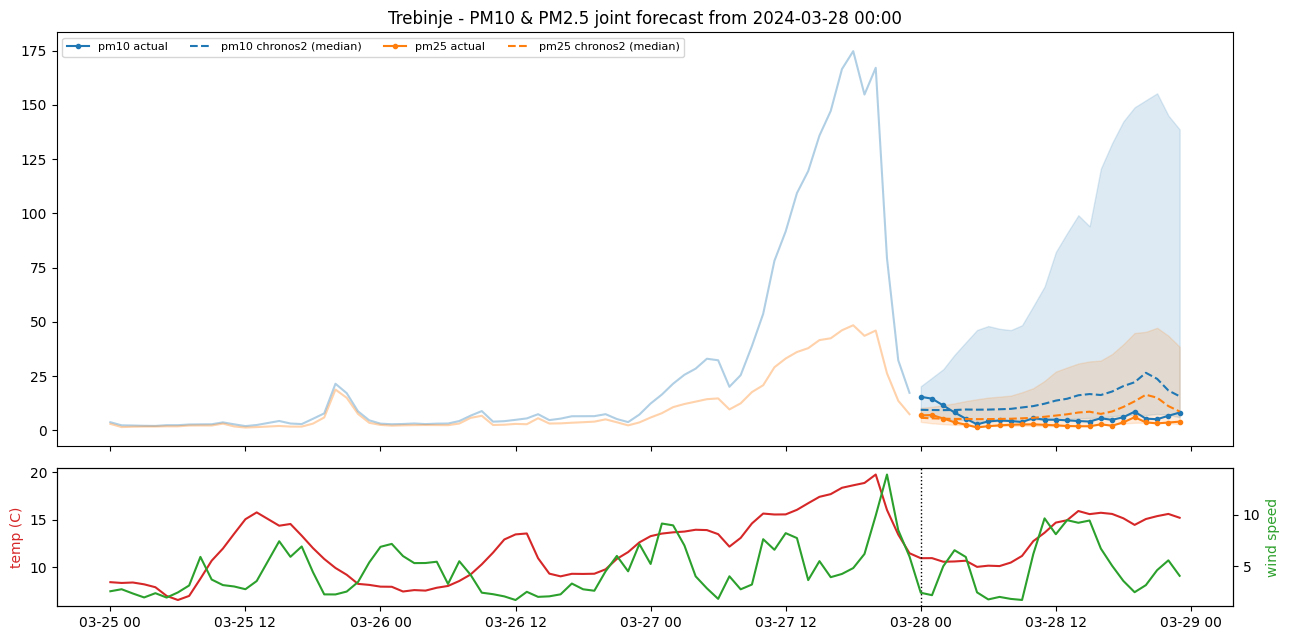

In [16]:
# The window where Chronos-2's joint PM10/PM25 call beat the t-24 bar by the
# most (ranked on PM10, the pollutant with denser station coverage), plotted
# alongside the weather that was fed in for that window as context.
t24 = base[base.model == "persistence_t24"].set_index(["station", "pollutant", "origin"]).mase
res_idx = res.set_index(["station", "pollutant", "origin"])
gain = (t24.reindex(res_idx.index).to_numpy() - res_idx.mase.to_numpy())
gain = pd.Series(gain, index=res_idx.index)
best = gain[gain.index.get_level_values("pollutant") == "pm10"].idxmax()
station, _, origin = best

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

uid = jobs.set_index(["station", "origin"]).loc[(station, origin)].uid

for target, color in zip(TARGETS, ["tab:blue", "tab:orange"]):
    s = panel[(station, target)]
    j = s.index.get_loc(origin)
    q = preds[(uid, target)]
    fut = s.index[j:j + HORIZON]
    y, mask = bs.target(panel, station, target, origin)

    ax1.plot(s.index[j - 72:j], s.y.to_numpy()[j - 72:j], color=color, alpha=.35)
    ax1.plot(fut, np.where(mask, y, np.nan), "o-", ms=3, color=color, label=f"{target} actual")
    ax1.plot(fut, q[:, MEDIAN], "--", color=color, label=f"{target} chronos2 (median)")
    ax1.fill_between(fut, q[:, 0], q[:, -1], alpha=.15, color=color)

ax1.set_title(f"{station} - PM10 & PM2.5 joint forecast from {pd.Timestamp(origin):%Y-%m-%d %H:%M}")
ax1.legend(ncol=4, fontsize=8)

wx = weather.get(station)
if wx is not None:
    wx_win = wx.reindex(pd.date_range(s.index[j - 72], fut[-1], freq="h"))
    ax2.plot(wx_win.index, wx_win["temperature"], color="tab:red", label="temp (C)")
    ax2b = ax2.twinx()
    ax2b.plot(wx_win.index, wx_win["wind_speed"], color="tab:green", label="wind speed")
    ax2.axvline(origin, color="k", ls=":", lw=1)
    ax2.set_ylabel("temp (C)", color="tab:red"); ax2b.set_ylabel("wind speed", color="tab:green")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "chronos2_example.png"), dpi=150)
plt.show()

## Save

In [ ]:
res.to_csv(os.path.join(RESULTS, "chronos2_window_metrics.csv"), index=False)
per_pol.to_csv(os.path.join(RESULTS, "chronos2_by_pollutant.csv"))
st.to_csv(os.path.join(RESULTS, "chronos2_by_station.csv"))
allm.groupby(["pollutant", "model"])[["mae", "rmse", "mase"]].mean().to_csv(
    os.path.join(RESULTS, "chronos2_vs_baselines.csv"))

meta = {
    "model": MODEL, "context_hours": CONTEXT, "horizon_hours": HORIZON,
    "zero_shot": True, "quantiles": QUANTILES, "targets": TARGETS,
    "use_weather": USE_WEATHER, "weather_vars": WEATHER_COLS if USE_WEATHER else [],
    "weather_future_is_oracle": True,
    "windows": int(len(jobs)), "series": int(jobs.station.nunique()),
    "shared_folder_id": SHARED_FOLDER_ID,
    "split": SPLIT["val"], "masking": SPLIT["masking"]["rule"],
}
with open(os.path.join(RESULTS, "chronos2_run.json"), "w") as f:
    json.dump(meta, f, indent=2, default=str)

print("written to", os.path.abspath(RESULTS))
for f in sorted(os.listdir(RESULTS)):
    print("  ", f)